# Exploração dos Dados
Análise exploratória dos ficheiros reddit_user_data_count.csv, subreddit_info.csv e reddit_data.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Carregamento

In [3]:
interactions = pd.read_csv('../data/raw/reddit_user_data_count.csv')
subreddits   = pd.read_csv('../data/raw/subreddit_info.csv')
reddit_data  = pd.read_csv('../data/raw/reddit_data.csv')

print('Interacções:', interactions.shape)
print('Subreddits: ', subreddits.shape)
print('Reddit data:', reddit_data.shape)

Interacções: (1738737, 3)
Subreddits:  (57856, 4)
Reddit data: (14000000, 3)


In [4]:
interactions.head()

,user,subreddit,count
0,------Username------,AskReddit,20
1,------Username------,Barca,9
2,------Username------,FIFA,4
3,------Username------,MMA,5
4,------Username------,RioGrandeValley,3


In [5]:
subreddits.head()

,subreddit,num_subscribers,over18,public_description
0,ChoosingBeggars,2134849.0,False,"This subreddit is for posting screenshots, pic..."
1,Python,809272.0,False,News about the programming language Python. If...
2,interestingasfuck,8092462.0,False,For anything that is InterestingAsFuck
3,PublicFreakout,3257059.0,False,"A subreddit dedicated to people freaking out, ..."
4,ShitMomGroupsSay,258681.0,False,Share the drama. \n\nEssential oils cure all? ...


## 2. Estatísticas básicas

In [6]:
print('Utilizadores únicos:', interactions['user'].nunique())
print('Subreddits únicos:  ', interactions['subreddit'].nunique())
print('\nDistribuição de count:')
print(interactions['count'].describe())

Utilizadores únicos: 37845
Subreddits únicos:   69490

Distribuição de count:
count    1.738737e+06
mean     1.121993e+01
std      4.809370e+01
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      6.000000e+00
max      1.096000e+03
Name: count, dtype: float64


## 3. Distribuição de interacções (lei de potência)

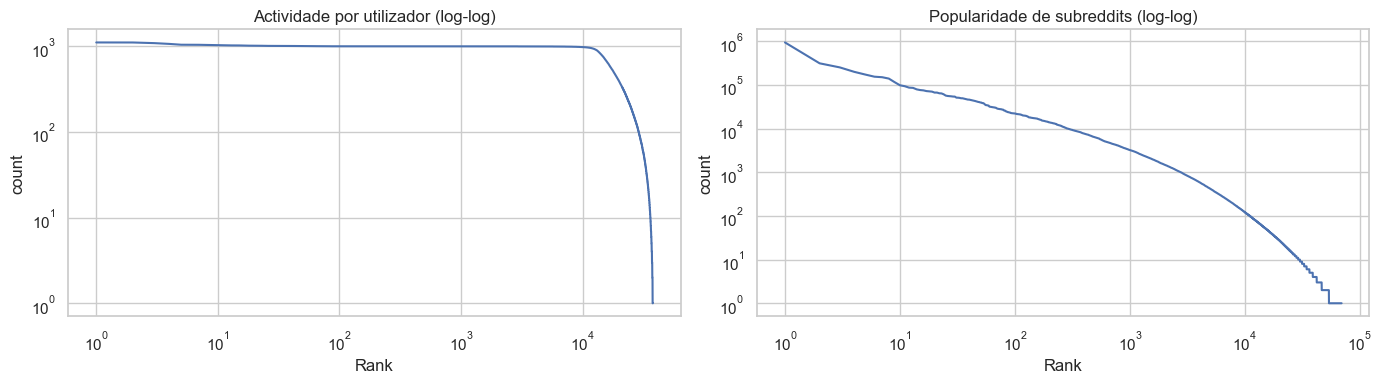

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Interacções por utilizador
user_activity = interactions.groupby('user')['count'].sum().sort_values(ascending=False)
axes[0].loglog(range(1, len(user_activity)+1), user_activity.values)
axes[0].set_title('Actividade por utilizador (log-log)')
axes[0].set_xlabel('Rank'); axes[0].set_ylabel('count')

# Popularidade de subreddits
sub_pop = interactions.groupby('subreddit')['count'].sum().sort_values(ascending=False)
axes[1].loglog(range(1, len(sub_pop)+1), sub_pop.values)
axes[1].set_title('Popularidade de subreddits (log-log)')
axes[1].set_xlabel('Rank'); axes[1].set_ylabel('count')

plt.tight_layout()
plt.savefig('../results/plots/eda_distributions.png', dpi=120)
plt.show()

## 4. Recompensa log-normalizada

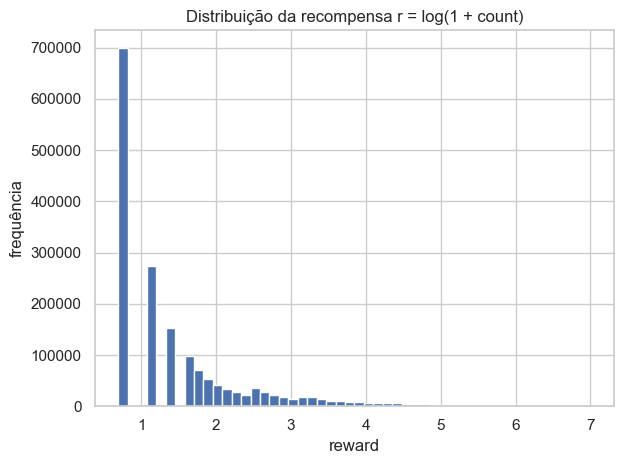

In [8]:
interactions['reward'] = np.log1p(interactions['count'])
interactions['reward'].hist(bins=50)
plt.title('Distribuição da recompensa r = log(1 + count)')
plt.xlabel('reward'); plt.ylabel('frequência')
plt.tight_layout()
plt.savefig('../results/plots/eda_reward_dist.png', dpi=120)
plt.show()

## 5. Subreddits over18

In [9]:
print('over18 counts:')
print(subreddits['over18'].value_counts())
print(f'\nFracção over18: {subreddits["over18"].mean():.2%}')

over18 counts:
over18
False    51618
True      6238
Name: count, dtype: int64

Fracção over18: 10.78%


## 6. Cobertura dos metadados

In [10]:
subs_in_interactions = set(interactions['subreddit'])
subs_with_meta       = set(subreddits['subreddit'])
covered = subs_in_interactions & subs_with_meta
print(f'Subreddits em interacções: {len(subs_in_interactions):,}')
print(f'Com metadados:             {len(covered):,}')
print(f'Cobertura:                 {len(covered)/len(subs_in_interactions):.1%}')

Subreddits em interacções: 69,490
Com metadados:             57,852
Cobertura:                 83.3%
